# MinIO — Sharded Parquet + DuckDB Benchmark

Simulates a real WSI layout:
- **100,000 Parquet shards**, each holding **1,000 patches** (100 M patches total).
- Each shard = one WSI: `wsi_{shard_id:06d}.parquet`.
- Patches are written **sorted by ID** within each shard so DuckDB can use row-group statistics for predicate pushdown.

Read query: given a random batch of patch IDs and knowledge of which shard each belongs to,
DuckDB opens **only the required shards** — no full scan.

## 0 — Start MinIO server

In [1]:
import os
import subprocess
import time
import urllib.request

MINIO_BIN  = '/tmp/minio'
MINIO_DATA = '/tmp/minio-data'
MINIO_PORT = 9000

if not os.path.exists(MINIO_BIN):
    print('Downloading minio binary...')
    urllib.request.urlretrieve(
        'https://dl.min.io/server/minio/release/linux-amd64/minio',
        MINIO_BIN
    )
    os.chmod(MINIO_BIN, 0o755)
    print('Downloaded.')

os.makedirs(MINIO_DATA, exist_ok=True)

check = subprocess.run(['pgrep', '-f', 'minio server'], capture_output=True)
if check.returncode == 0:
    print('MinIO already running.')
else:
    env = os.environ.copy()
    env['MINIO_ROOT_USER']     = 'minioadmin'
    env['MINIO_ROOT_PASSWORD'] = 'minioadmin'
    proc = subprocess.Popen(
        [MINIO_BIN, 'server', MINIO_DATA, '--address', f':{MINIO_PORT}'],
        env=env,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    time.sleep(2)
    if proc.poll() is not None:
        raise RuntimeError(f'MinIO exited immediately (code {proc.returncode})')
    print(f'MinIO started (pid {proc.pid}) on port {MINIO_PORT}.')

MinIO already running.


## 1 — Configuration

In [2]:
import io
import random
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from multiprocessing import cpu_count

import boto3
import duckdb
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from botocore.client import Config
from PIL import Image
from tqdm import tqdm

MINIO_ENDPOINT    = 'http://127.0.0.1:9000'
MINIO_ACCESS      = 'minioadmin'
MINIO_SECRET      = 'minioadmin'
BUCKET            = 'patches-sharded'

N_SHARDS          = 1000   # one per WSI
PATCHES_PER_SHARD = 100_000     # patches per WSI
TOTAL_PATCHES     = N_SHARDS * PATCHES_PER_SHARD  # 100 M

IMAGE_SIZE        = (64, 64, 3)
N_UPLOAD_WORKERS  = cpu_count() * 2

N_READS           = 1_000     # random patches to fetch in the read benchmark

def shard_key(patch_id: int) -> int:
    """Return the shard (WSI) index that owns this patch ID."""
    return patch_id // PATCHES_PER_SHARD

def shard_s3_key(shard_id: int) -> str:
    return f'wsi_{shard_id:06d}.parquet'

print(f'Total patches: {TOTAL_PATCHES:,}  |  Shards: {N_SHARDS:,}  |  Workers: {N_UPLOAD_WORKERS}')

Total patches: 100,000,000  |  Shards: 1,000  |  Workers: 64


## 2 — Create bucket

In [3]:
s3 = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS,
    aws_secret_access_key=MINIO_SECRET,
    config=Config(signature_version='s3v4'),
    region_name='us-east-1',
)

existing = [b['Name'] for b in s3.list_buckets().get('Buckets', [])]
if BUCKET not in existing:
    s3.create_bucket(Bucket=BUCKET)
    print(f'Created bucket: {BUCKET}')
else:
    print(f'Bucket {BUCKET!r} already exists.')

Bucket 'patches-sharded' already exists.


## 3 — Generate & upload all shards

Each shard is built in memory (no local disk), then streamed straight to MinIO.
All `N_UPLOAD_WORKERS` threads reuse one pre-generated JPEG to keep CPU overhead low.

In [4]:
import threading

SCHEMA = pa.schema([
    pa.field('id',         pa.int32()),
    pa.field('image_data', pa.large_binary()),
])

def generate_jpeg_bytes() -> bytes:
    arr = np.random.randint(0, 256, IMAGE_SIZE, dtype=np.uint8)
    buf = io.BytesIO()
    Image.fromarray(arr).save(buf, format='JPEG', quality=85)
    return buf.getvalue()

_SHARED_JPEG = generate_jpeg_bytes()

# Thread-local S3 clients — eliminates lock contention on the shared client
_thread_local = threading.local()

def get_s3_client():
    if not hasattr(_thread_local, 's3'):
        _thread_local.s3 = boto3.client(
            's3',
            endpoint_url=MINIO_ENDPOINT,
            aws_access_key_id=MINIO_ACCESS,
            aws_secret_access_key=MINIO_SECRET,
            config=Config(signature_version='s3v4'),
            region_name='us-east-1',
        )
    return _thread_local.s3

def build_and_upload_shard(shard_id: int) -> None:
    start_id = shard_id * PATCHES_PER_SHARD
    ids      = list(range(start_id, start_id + PATCHES_PER_SHARD))
    table    = pa.table(
        {'id': ids, 'image_data': [_SHARED_JPEG] * PATCHES_PER_SHARD},
        schema=SCHEMA
    )
    buf = io.BytesIO()
    pq.write_table(table, buf, compression='snappy')
    # put_object avoids multipart-upload overhead for small objects
    get_s3_client().put_object(Bucket=BUCKET, Key=shard_s3_key(shard_id), Body=buf.getvalue())


t0 = time.perf_counter()

with ThreadPoolExecutor(max_workers=N_UPLOAD_WORKERS) as executor:
    futures = {executor.submit(build_and_upload_shard, i): i for i in range(N_SHARDS)}
    for f in tqdm(as_completed(futures), total=N_SHARDS, desc='Uploading shards'):
        f.result()

elapsed = time.perf_counter() - t0
print(f'\nUploaded {N_SHARDS:,} shards in {elapsed:.1f}s  ({N_SHARDS/elapsed:,.0f} shards/sec)')
print(f'Effective patch throughput: {TOTAL_PATCHES/elapsed:,.0f} patches/sec')


Uploading shards: 100%|██████████| 1000/1000 [08:26<00:00,  1.98it/s]


Uploaded 1,000 shards in 506.8s  (2 shards/sec)
Effective patch throughput: 197,309 patches/sec


## 4 — Configure DuckDB → MinIO

In [5]:
con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')
con.execute(f"""
    SET s3_endpoint          = '127.0.0.1:{MINIO_PORT}';
    SET s3_access_key_id     = '{MINIO_ACCESS}';
    SET s3_secret_access_key = '{MINIO_SECRET}';
    SET s3_use_ssl           = false;
    SET s3_url_style         = 'path';
""")
print('DuckDB S3/MinIO configured.')

DuckDB S3/MinIO configured.


## 5 — Read Benchmark

For each sampled patch ID we resolve its shard with `shard_key(patch_id)`.
DuckDB receives only the **unique shard URLs** that are needed — the rest of the 100k files are never opened.

In [6]:
sample_ids = random.sample(range(TOTAL_PATCHES), N_READS)

# Resolve each ID to its shard URL — O(1) arithmetic, no index lookup needed
shard_urls = list({
    f's3://{BUCKET}/{shard_s3_key(shard_key(pid))}'
    for pid in sample_ids
})

print(f'Querying {len(shard_urls):,} unique shards for {N_READS:,} patches '
      f'(out of {N_SHARDS:,} total shards)')

ids_sql     = ', '.join(str(i) for i in sample_ids)
urls_sql    = ', '.join(f"'{u}'" for u in shard_urls)

query = f"""
    SELECT id, image_data
    FROM read_parquet([{urls_sql}])
    WHERE id IN ({ids_sql})
"""

t0 = time.perf_counter()
result = con.execute(query).fetchall()
elapsed = time.perf_counter() - t0

print(f'Fetched {len(result):,} patches in {elapsed*1000:.1f} ms  ({len(result)/elapsed:,.0f} reads/sec)')
if len(result) < N_READS:
    print(f'WARNING: expected {N_READS}, got {len(result)} (misses: {N_READS - len(result)})')

Querying 642 unique shards for 1,000 patches (out of 1,000 total shards)
Fetched 1,000 patches in 317.7 ms  (3,147 reads/sec)


## 5b — Multiprocessing Read Benchmark

Split the same `N_READS` patch IDs across *N* worker processes, each running its own DuckDB connection.  
Measures wall-clock throughput as a function of process count to reveal parallelisability.

   1 worker(s): 1,000 patches in 543 ms  →  1,842 reads/sec
   2 worker(s): 1,000 patches in 597 ms  →  1,674 reads/sec
   4 worker(s): 1,000 patches in 806 ms  →  1,241 reads/sec
   8 worker(s): 1,000 patches in 1101 ms  →  908 reads/sec
  16 worker(s): 1,000 patches in 1738 ms  →  575 reads/sec


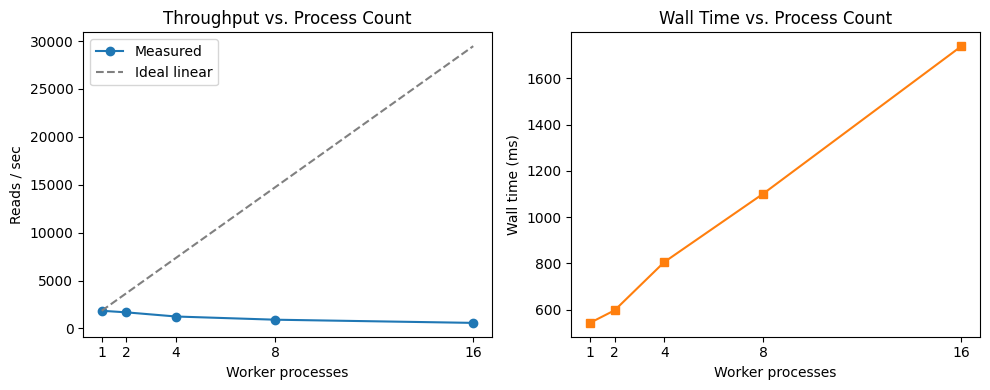


Parallel efficiency (1.0 = perfect linear scaling):
   1 workers: 1.00
   2 workers: 0.45
   4 workers: 0.17
   8 workers: 0.06
  16 workers: 0.02


In [7]:
import multiprocessing as mp
import math
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------- #
# Worker: runs in a separate process, returns (n_fetched, elapsed_seconds)    #
# --------------------------------------------------------------------------- #
def _read_worker(args):
    patch_ids, minio_port, minio_access, minio_secret, bucket, patches_per_shard = args
    import duckdb, time

    def _shard_key(pid):
        return pid // patches_per_shard

    def _shard_s3_key(sid):
        return f'wsi_{sid:06d}.parquet'

    shard_urls = list({
        f's3://{bucket}/{_shard_s3_key(_shard_key(pid))}'
        for pid in patch_ids
    })

    ids_sql  = ', '.join(str(i) for i in patch_ids)
    urls_sql = ', '.join(f"'{u}'" for u in shard_urls)

    con = duckdb.connect()
    con.execute('INSTALL httpfs; LOAD httpfs;')
    con.execute(f"""
        SET s3_endpoint          = '127.0.0.1:{minio_port}';
        SET s3_access_key_id     = '{minio_access}';
        SET s3_secret_access_key = '{minio_secret}';
        SET s3_use_ssl           = false;
        SET s3_url_style         = 'path';
    """)

    query = f"""
        SELECT id, image_data
        FROM read_parquet([{urls_sql}])
        WHERE id IN ({ids_sql})
    """
    t0 = time.perf_counter()
    rows = con.execute(query).fetchall()
    elapsed = time.perf_counter() - t0
    con.close()
    return len(rows), elapsed


# --------------------------------------------------------------------------- #
# Sweep over process counts                                                    #
# --------------------------------------------------------------------------- #
MAX_WORKERS   = min(mp.cpu_count(), 16)
worker_counts = [1, 2, 4, 8, MAX_WORKERS] if MAX_WORKERS > 8 else [1, 2, 4, MAX_WORKERS]
worker_counts = sorted(set(worker_counts))   # deduplicate

# Use a fresh sample that's large enough to spread across workers
BENCH_READS = max(N_READS, 1_000)
bench_ids   = random.sample(range(TOTAL_PATCHES), BENCH_READS)

worker_cfg = (MINIO_PORT, MINIO_ACCESS, MINIO_SECRET, BUCKET, PATCHES_PER_SHARD)

results_mp = {}   # n_workers -> (total_patches, wall_seconds, reads_per_sec)

for n_workers in worker_counts:
    # Partition IDs as evenly as possible across workers
    chunk_size = math.ceil(BENCH_READS / n_workers)
    chunks     = [bench_ids[i:i + chunk_size] for i in range(0, BENCH_READS, chunk_size)]

    args = [(chunk, *worker_cfg) for chunk in chunks]

    wall_t0 = time.perf_counter()
    with mp.Pool(processes=n_workers) as pool:
        worker_results = pool.map(_read_worker, args)
    wall_elapsed = time.perf_counter() - wall_t0

    total_fetched = sum(r[0] for r in worker_results)
    rps           = total_fetched / wall_elapsed
    results_mp[n_workers] = (total_fetched, wall_elapsed, rps)
    print(f'  {n_workers:2d} worker(s): {total_fetched:,} patches in '
          f'{wall_elapsed*1000:.0f} ms  →  {rps:,.0f} reads/sec')

# --------------------------------------------------------------------------- #
# Plot                                                                         #
# --------------------------------------------------------------------------- #
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

xs       = list(results_mp.keys())
rps_vals = [results_mp[n][2] for n in xs]
lat_vals = [results_mp[n][1] * 1000 for n in xs]   # ms

ideal_rps = [results_mp[1][2] * n for n in xs]

ax0 = axes[0]
ax0.plot(xs, rps_vals,  'o-', label='Measured')
ax0.plot(xs, ideal_rps, '--', color='grey', label='Ideal linear')
ax0.set_xlabel('Worker processes')
ax0.set_ylabel('Reads / sec')
ax0.set_title('Throughput vs. Process Count')
ax0.set_xticks(xs)
ax0.legend()

ax1 = axes[1]
ax1.plot(xs, lat_vals, 's-', color='tab:orange')
ax1.set_xlabel('Worker processes')
ax1.set_ylabel('Wall time (ms)')
ax1.set_title('Wall Time vs. Process Count')
ax1.set_xticks(xs)

plt.tight_layout()
plt.show()

efficiency = {n: results_mp[n][2] / (results_mp[1][2] * n) for n in xs}
print('\nParallel efficiency (1.0 = perfect linear scaling):')
for n, e in efficiency.items():
    print(f'  {n:2d} workers: {e:.2f}')


## 6 — Visualise a sample

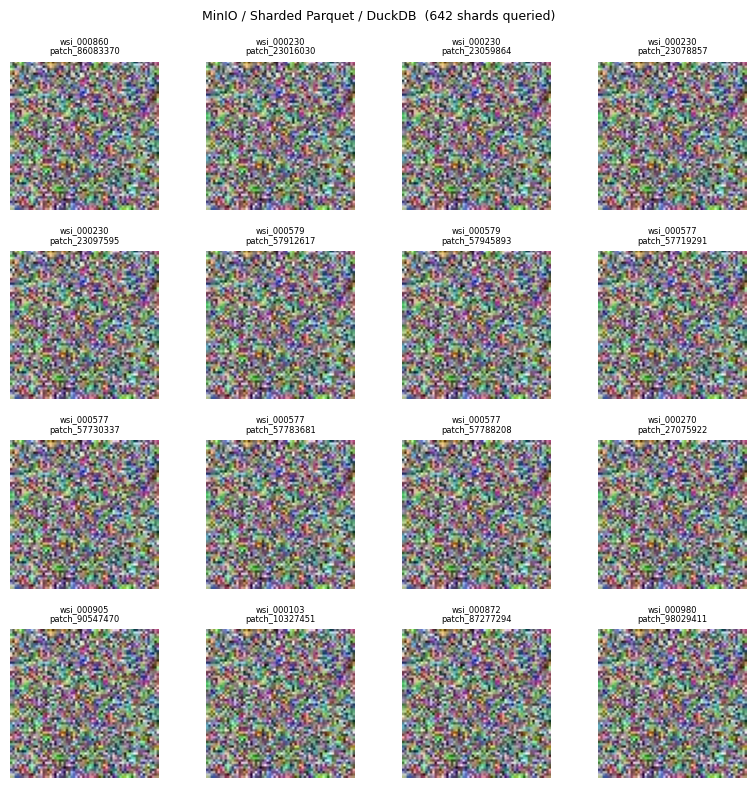

In [8]:
import matplotlib.pyplot as plt

N_PLOT = 16
sample = result[:N_PLOT]

cols = 4
rows = (N_PLOT + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = np.array(axes).flatten()

for ax, (img_id, jpeg_bytes) in zip(axes, sample):
    arr = np.array(Image.open(io.BytesIO(bytes(jpeg_bytes))))
    ax.imshow(arr)
    ax.set_title(f'wsi_{shard_key(img_id):06d}\npatch_{img_id}', fontsize=6)
    ax.axis('off')

for ax in axes[N_PLOT:]:
    ax.set_visible(False)

plt.suptitle(f'MinIO / Sharded Parquet / DuckDB  ({len(shard_urls)} shards queried)', fontsize=9)
plt.tight_layout()
plt.show()